# Varian 01 — Single Layer (Baseline Linier)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/01_single_layer.ipynb)

**Anggota yang mengerjakan:** _Stevan_

---

## 🏗️ Arsitektur
Single-layer network: **input langsung ke output**, tanpa hidden layer. Ini setara dengan logistic regression multi-kelas (sesuai sub-bab 2.2 di slide).

## ⚡ Fungsi Aktivasi
Tidak ada fungsi aktivasi di hidden layer (karena tidak ada hidden layer). Output layer menggunakan **softmax** untuk klasifikasi 3 kelas.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [1]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-sawit-supremacy.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 27 (delta 5), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (27/27), 21.02 KiB | 3.50 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


## 2. Import library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [3]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [4]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(n_classes, activation='softmax'),  # langsung ke output
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 1s - 115ms/step - accuracy: 0.2188 - loss: 2.0837 - val_accuracy: 0.1667 - val_loss: 1.9985
Epoch 2/100
12/12 - 0s - 9ms/step - accuracy: 0.2188 - loss: 2.0308 - val_accuracy: 0.1667 - val_loss: 1.9549
Epoch 3/100
12/12 - 0s - 9ms/step - accuracy: 0.2188 - loss: 1.9789 - val_accuracy: 0.1667 - val_loss: 1.9119
Epoch 4/100
12/12 - 0s - 9ms/step - accuracy: 0.2188 - loss: 1.9278 - val_accuracy: 0.1250 - val_loss: 1.8695
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.2188 - loss: 1.8775 - val_accuracy: 0.1250 - val_loss: 1.8277
Epoch 6/100
12/12 - 0s - 9ms/step - accuracy: 0.2292 - loss: 1.8281 - val_accuracy: 0.1250 - val_loss: 1.7866
Epoch 7/100
12/12 - 0s - 10ms/step - accuracy: 0.2396 - loss: 1.7797 - val_accuracy: 0.1250 - val_loss: 1.7462
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 0.2604 - loss: 1.7322 - val_accuracy: 0.1250 - val_loss: 1.7066
Epoch 9/100
12/12 - 0s - 10ms/step - accuracy: 0.2604 - loss: 1.6856 - val_accuracy: 0.1250 - val_loss: 1.6677
Epoch 

## 6. Visualisasi kurva training

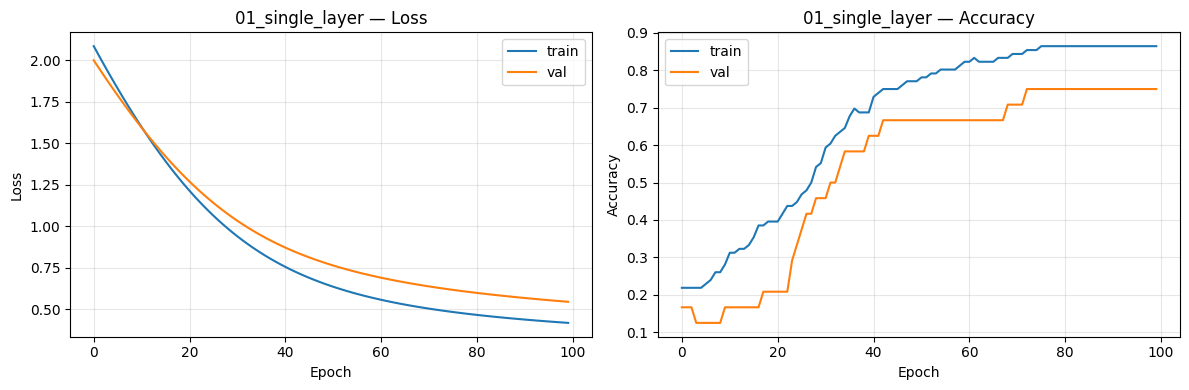

In [6]:
plot_training_curves(history, variant_name='01_single_layer')


## 7. Evaluasi di test set

In [7]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='01_single_layer')
save_history(history, variant_name='01_single_layer')
summary



📊 01_single_layer
   Test loss:     0.5789
   Test accuracy: 0.7667
   Jumlah parameter: 15
✅ History tersimpan di: results/01_single_layer.csv


{'variant': '01_single_layer',
 'test_loss': 0.578898012638092,
 'test_accuracy': 0.7666666507720947,
 'n_params': 15}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Berapa total jumlah parameter model ini? Bandingkan dengan varian multi-layer.

**Total Parameter Model Ini:** Jika model ini adalah single-layer linear network (seperti Softmax/Logistic Regression) untuk dataset Iris, maka input memiliki 4 fitur (sepal length, sepal width, petal length, petal width) dan output memiliki 3 kelas (Setosa, Versicolor, Virginica).$$\text{Bobot (Weights)} = 4 \times 3 = 12$$$$\text{Bias} = 3$$Total parameter = $12 + 3 = 15$ parameter. (Catatan: Jika modelmu hanya menggunakan binary classification dengan 1 output node, totalnya adalah $4 \text{ bobot} + 1 \text{ bias} = 5$ parameter).

**Perbandingan dengan Varian Multi-layer:** Varian multi-layer (seperti MLP/Multi-Layer Perceptron) memiliki jumlah parameter yang jauh lebih besar. Hal ini karena adanya tambahan hidden layer di antara input dan output. Setiap neuron di hidden layer akan memiliki bobot tersendiri terhadap seluruh input dan seluruh output, sehingga kapasitas penyimpanan pola model meningkat secara eksponensial seiring bertambahnya jumlah hidden units.

2. Menurutmu, apakah model ini cukup ekspresif untuk Iris? Mengapa?

Cukup ekspresif untuk memisahkan sebagian kelas, namun kurang ekspresif untuk memisahkan seluruh 3 kelas Iris secara sempurna.
**Hal ini terjadi karena** model single-layer hanya mampu menghasilkan decision boundary (batas keputusan) yang bersifat linear (garis lurus atau hyperplane). Pada dataset Iris, spesies Setosa memang terpisah secara linear sempurna (linearly separable) dari spesies lainnya. Namun, spesies Versicolor dan Virginica memiliki area fitur yang saling tumpang tindih (overlap) dan tidak dapat dipisahkan secara sempurna hanya dengan garis lurus. Oleh karena itu, model ini akan mengalami batasan akurasi pada kedua kelas tersebut.

3. Jika dataset diganti dengan yang non-linear separable (mis. XOR), apa prediksimu?

Prediksinya adalah performa model akan menurun drastis dan model akan gagal mempelajari pola tersebut (akurasi maksimal hanya sekitar 75% untuk kasus XOR 2-bit).
**Hal ini terjadi karena** masalah XOR adalah masalah non-linear klasik yang secara matematis tidak mungkin diselesaikan menggunakan satu garis lurus tunggal. karena model single-layer tidak memiliki hidden layer dan fungsi aktivasi non-linear di dalamnya, model ini tidak mampu mentransformasikan ruang fitur untuk membuat pola yang rumit. Untuk menyelesaikan masalah non-linear seperti XOR, mutlak diperlukan varian multi-layer yang dilengkapi fungsi aktivasi non-linear (seperti ReLU atau Sigmoid).


_Tulis jawabanmu di sini..._